**WALMART SALES ANALYSIS**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [ ]:
df=pd.read_csv("/content/Walmart Data Analysis and Forcasting.csv")
df

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106
...,...,...,...,...,...,...,...,...
6430,45,28-09-2012,713173.95,0,64.88,3.997,192.013558,8.684
6431,45,05-10-2012,733455.07,0,64.89,3.985,192.170412,8.667
6432,45,12-10-2012,734464.36,0,54.47,4.000,192.327265,8.667
6433,45,19-10-2012,718125.53,0,56.47,3.969,192.330854,8.667


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [ ]:
df.isnull().sum()

,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['Date']=pd.to_datetime(df['Date'], format='%d-%m-%Y')
df['Date']

,Date
0,2010-02-05
1,2010-02-12
2,2010-02-19
3,2010-02-26
4,2010-03-05
...,...
6430,2012-09-28
6431,2012-10-05
6432,2012-10-12
6433,2012-10-19


In [ ]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

In [ ]:
df = df.drop('Date', axis=1)

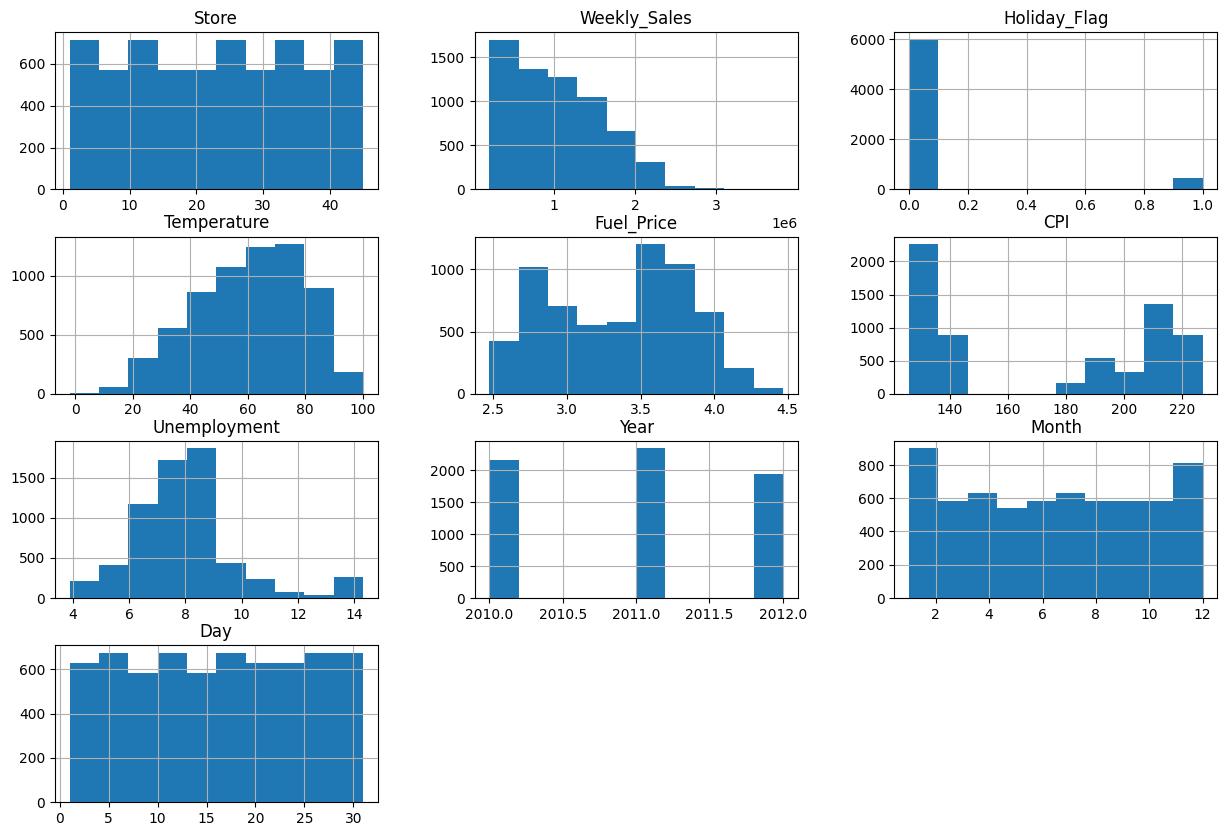

In [ ]:
df.hist(figsize=(15,10))
plt.show()

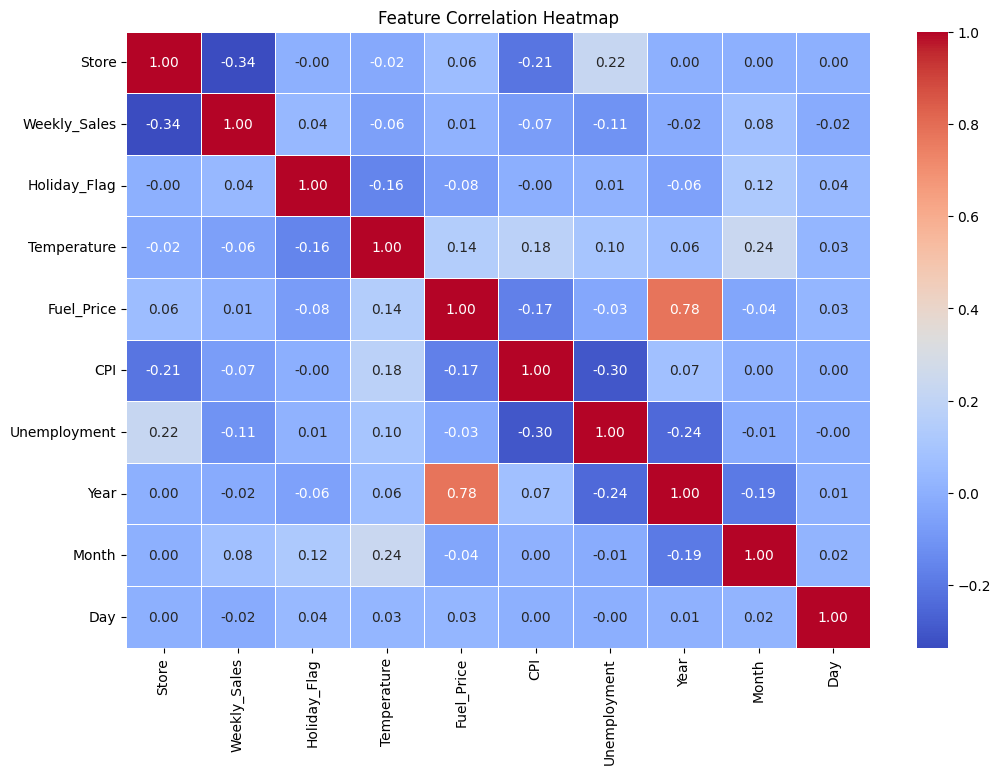

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm",fmt=".2f",linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

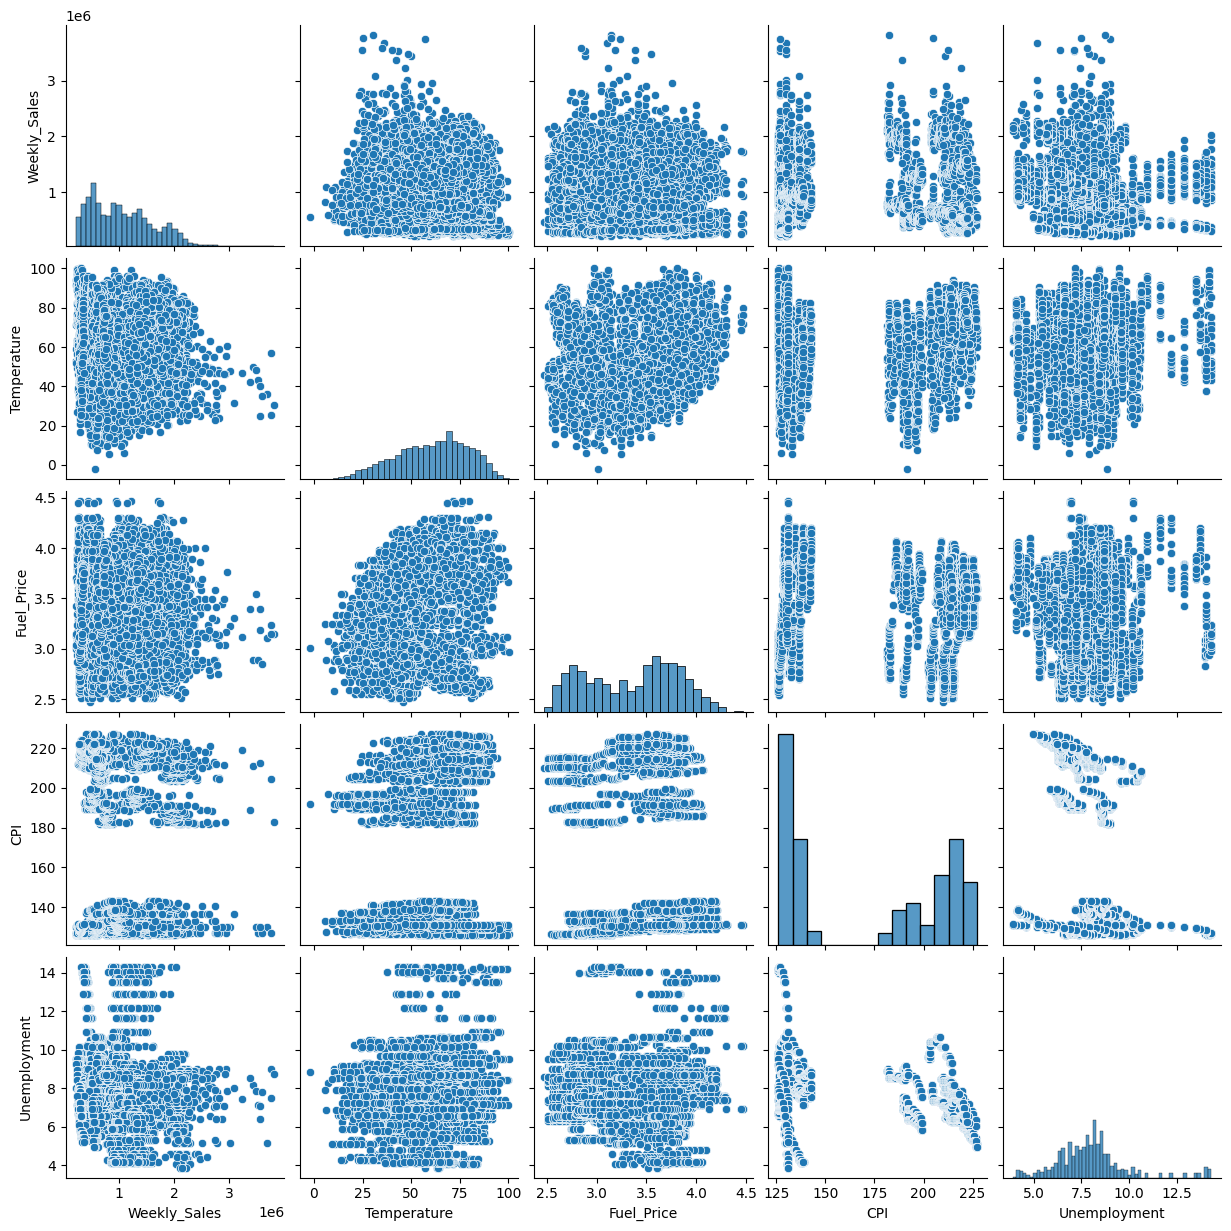

In [ ]:
sns.pairplot(df[['Weekly_Sales','Temperature','Fuel_Price','CPI','Unemployment']])
plt.show()

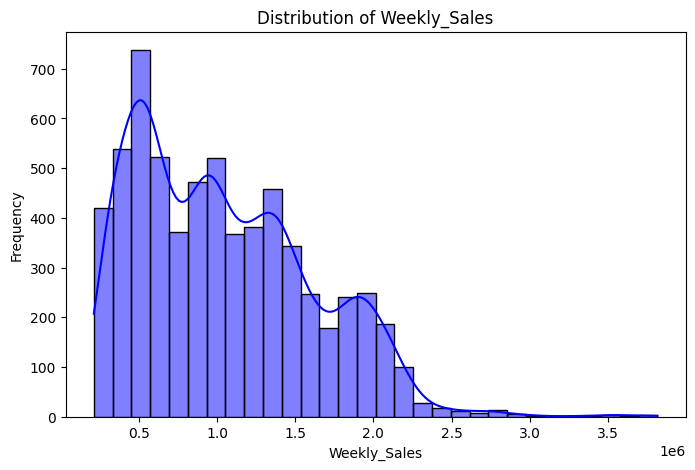

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Weekly_Sales'],bins=30,kde=True,color='blue')
plt.title("Distribution of Weekly_Sales")
plt.xlabel("Weekly_Sales")
plt.ylabel("Frequency")
plt.show()

**MODEL BUILDING**

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42)
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
r2_rf = r2_score(y_test, y_pred_rf)

rmse_rf = mean_squared_error(
    y_test,
    y_pred_rf
) ** 0.5

print(f"R² Score: {r2_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")

R² Score: 0.9596
RMSE: 114026.7410


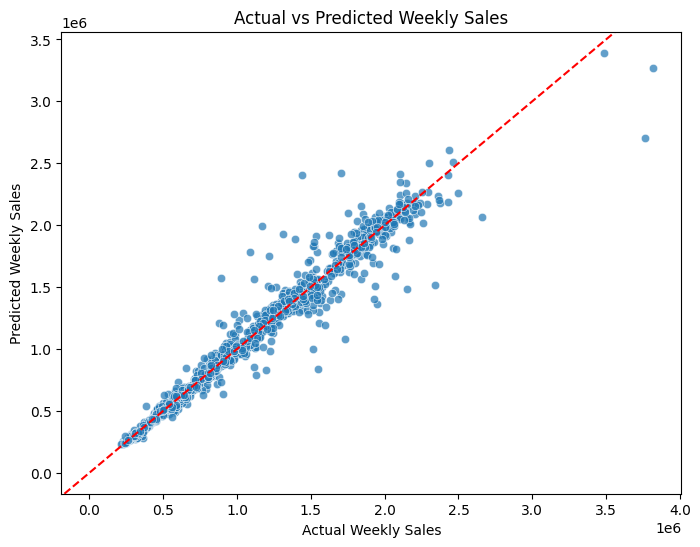

In [ ]:
#Scatter plot of actual vs predicted values
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test,y=y_pred_rf,alpha=0.7)
plt.xlabel("Actual Weekly Sales")
plt.ylabel("Predicted Weekly Sales")
plt.title("Actual vs Predicted Weekly Sales")
plt.axline([0,0],[1,1],color="red",linestyle="--")
plt.show()

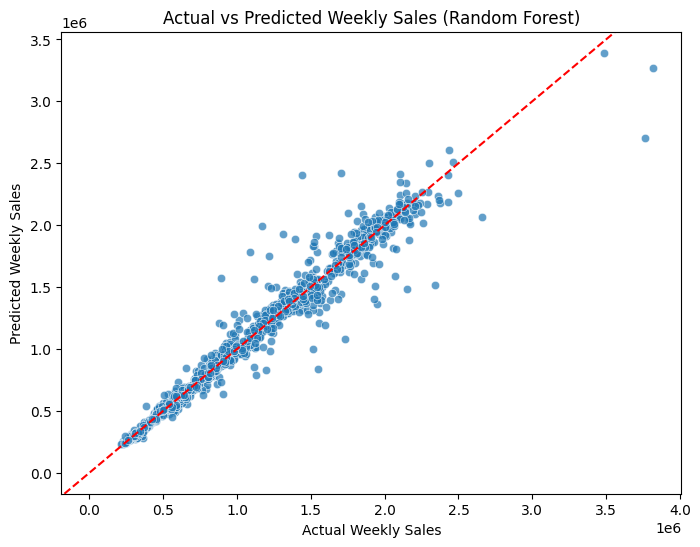

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=y_test,
    y=y_pred_rf,
    alpha=0.7
)
plt.xlabel("Actual Weekly Sales")
plt.ylabel("Predicted Weekly Sales")
plt.title("Actual vs Predicted Weekly Sales (Random Forest)")
plt.axline(
    [0, 0],
    [1, 1],
    color="red",
    linestyle="--"
)
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import joblib

# Load the trained Random Forest Regressor model
rf_model = joblib.load('random_forest_regressor_model.pkl')

# Define feature values manually using input()
print("Enter the following details to predict Weekly Sales:")
store = float(input("Store Number: "))
holiday_input = input("Holiday Flag (0 for No, 1 for Yes): ")
holiday_flag = float(holiday_input)
temperature = float(input("Temperature: "))
fuel_price = float(input("Fuel Price: "))
cpi = float(input("CPI (Consumer Price Index): "))
unemployment = float(input("Unemployment Rate: "))
year = float(input("Year (e.g., 2010): "))
month = float(input("Month (1-12): "))
day = float(input("Day (1-31): "))

# Create DataFrame with all features matching training data
input_df = pd.DataFrame([{
    "Store": store,
    "Holiday_Flag": holiday_flag,
    "Temperature": temperature,
    "Fuel_Price": fuel_price,
    "CPI": cpi,
    "Unemployment": unemployment,
    "Year": year,
    "Month": month,
    "Day": day
}])

# No preprocessing steps (like log or power transformation, or polynomial features)
# are needed here because the RandomForestRegressor was trained on the raw features.

# Ensure column order matches training data
# The order of columns in X_train was: Store, Holiday_Flag, Temperature, Fuel_Price, CPI, Unemployment, Year, Month, Day
ordered_input_df = input_df[["Store", "Holiday_Flag", "Temperature", "Fuel_Price", "CPI", "Unemployment", "Year", "Month", "Day"]]

# Predict Weekly Sales
prediction = rf_model.predict(ordered_input_df)[0]

print(f"Predicted Weekly Sales: ${prediction:,.2f}")

Enter the following details to predict Weekly Sales:
Store Number: 5
Holiday Flag (0 for No, 1 for Yes): 0
Temperature: 72.5
Fuel Price: 3.45
CPI (Consumer Price Index): 215.8
Unemployment Rate: 7.2
Year (e.g., 2010): 2010
Month (1-12): 5
Day (1-31): 26
Predicted Weekly Sales: $333,749.08


In [ ]:
! pip install streamlit -q

In [ ]:
%%writefile app.py
import streamlit as st
import joblib
import pandas as pd
import numpy as np

# Load the trained Random Forest Regressor model
rf_model = joblib.load('random_forest_regressor_model.pkl')

# Streamlit UI
st.title('🛒 Walmart Weekly Sales Prediction')
st.write('Enter the features below to predict the weekly sales.')

# Input fields for the features
store = st.number_input('Store Number (1-45)', min_value=1, max_value=45, value=1)
holiday_flag_input = st.selectbox('Holiday Flag (0: No Holiday, 1: Holiday)', options=[0, 1])
temperature = st.number_input('Temperature (in Fahrenheit)', value=50.0)
fuel_price = st.number_input('Fuel Price', value=3.0)
cpi = st.number_input('CPI (Consumer Price Index)', value=200.0)
unemployment = st.number_input('Unemployment Rate', value=8.0)
year = st.number_input('Year (e.g., 2010)', min_value=2010, max_value=2012, value=2010)
month = st.number_input('Month (1-12)', min_value=1, max_value=12, value=1)
day = st.number_input('Day (1-31)', min_value=1, max_value=31, value=1)


# Predict Weekly Sales
if st.button('Predict Weekly Sales'):
    # Create a DataFrame from the input values, matching the training features
    input_data = {
        "Store": [float(store)],
        "Holiday_Flag": [float(holiday_flag_input)],
        "Temperature": [float(temperature)],
        "Fuel_Price": [float(fuel_price)],
        "CPI": [float(cpi)],
        "Unemployment": [float(unemployment)],
        "Year": [float(year)],
        "Month": [float(month)],
        "Day": [float(day)]
    }

    input_df = pd.DataFrame(input_data)

    # The Random Forest model was trained on raw features, so no preprocessing is needed here
    # Ensure column order matches training data if necessary (though RF is robust to order if names match)
    # The order of columns in X_train was: Store, Holiday_Flag, Temperature, Fuel_Price, CPI, Unemployment, Year, Month, Day
    ordered_input_df = input_df[["Store", "Holiday_Flag", "Temperature", "Fuel_Price", "CPI", "Unemployment", "Year", "Month", "Day"]]

    predicted_sales = rf_model.predict(ordered_input_df)[0]
    st.success(f'Predicted Weekly Sales: ${predicted_sales:,.2f}')

Overwriting app.py


In [ ]:
!wget -q -O - ipv4.icanhazip.com

34.26.156.161


In [ ]:
!streamlit run app.py & npx localtunnel --port 8501

⠙⠹

⠸⠼⠴⠦2026-07-23 15:35:57.311 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.26.156.161:8501

your url is: https://six-tools-eat.loca.lt
Y
  Stopping...
^C
